# Goals

Goal:
- analyze thematic structure
- compare characters semantically
- study narrative context using NLP methods

Methods:
- TF-IDF
- LDA
- SBERT embeddings
- cosine similarity
- t-SNE visualization

## imports & load file

In [28]:
import re
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

In [2]:
with open("dune.txt", "r", encoding="Windows-1252") as f:
    text = f.read()

In [3]:
print(text[:1000])


DUNE



Book One

A beginning is the time for taking the most delicate care that the balances are correct. This every sister of the Bene Gesserit knows. To begin your study of the life of Muad'Dib, then, take care that you first place him in his time: born in the 57th year of the Padishah Emperor, Shaddam IV. And take the most special care that you locate Muad'Dib in his place: the planet Arrakis. Do not be deceived by the fact that he was born on Caladan and lived his first fifteen years there. Arrakis, the planet known as Dune, is forever his place.

—from "Manual of Muad'Dib" by the Princess Irulan


In the week before their departure to Arrakis, when all the final scurrying about had reached a nearly unbearable frenzy, an old crone came to visit the mother of the boy, Paul.

It was a warm night at Castle Caladan, and the ancient pile of stone that had served the Atreides family as home for twenty-six generations bore that cooled-sweat feeling it acquired before a change in the wea

# Basic frequency analysis of words and characters

The most frequent words in the text are either character names (Paul, Jessica, Duke, Hawat), verbs (see, think, come), or nouns related to people and human interaction (eye, hand, mother, Fremen).

Even this very surface-level analysis already suggests that Dune is primarily focused on characters, their relationships, and their personal experiences rather than on abstract worldbuilding alone.

In [4]:
text = re.sub(r'\s+', ' ', text)
print(text[:500])

 DUNE Book One A beginning is the time for taking the most delicate care that the balances are correct. This every sister of the Bene Gesserit knows. To begin your study of the life of Muad'Dib, then, take care that you first place him in his time: born in the 57th year of the Padishah Emperor, Shaddam IV. And take the most special care that you locate Muad'Dib in his place: the planet Arrakis. Do not be deceived by the fact that he was born on Caladan and lived his first fifteen years there. Ar


In [5]:
text = re.sub(r'[^A-Za-zА-Яа-яЁё ]+', '', text)
print(text[:500])

 DUNE Book One A beginning is the time for taking the most delicate care that the balances are correct This every sister of the Bene Gesserit knows To begin your study of the life of MuadDib then take care that you first place him in his time born in the th year of the Padishah Emperor Shaddam IV And take the most special care that you locate MuadDib in his place the planet Arrakis Do not be deceived by the fact that he was born on Caladan and lived his first fifteen years there Arrakis the plan


In [6]:
text = text.lower()
print(text[:1000])

 dune book one a beginning is the time for taking the most delicate care that the balances are correct this every sister of the bene gesserit knows to begin your study of the life of muaddib then take care that you first place him in his time born in the th year of the padishah emperor shaddam iv and take the most special care that you locate muaddib in his place the planet arrakis do not be deceived by the fact that he was born on caladan and lived his first fifteen years there arrakis the planet known as dune is forever his place from manual of muaddib by the princess irulan in the week before their departure to arrakis when all the final scurrying about had reached a nearly unbearable frenzy an old crone came to visit the mother of the boy paul it was a warm night at castle caladan and the ancient pile of stone that had served the atreides family as home for twentysix generations bore that cooledsweat feeling it acquired before a change in the weather the old woman was let in by the

In [7]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 1_200_000

In [8]:
chunk_size = 100_000
tokens = []

for i in range(0, len(text), chunk_size):
    chunk = text[i:i+chunk_size]
    doc = nlp(chunk)
    tokens.extend([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])

In [9]:
tokens = [t for t in tokens if t not in ['s', 've', 't', 'm', 'd']]

In [10]:
word_freq = Counter(tokens)
print(word_freq.most_common(20))

[('say', 2329), ('paul', 1574), ('jessica', 860), ('think', 813), ('man', 740), ('know', 656), ('duke', 572), ('baron', 572), ('not', 569), ('see', 561), ('hand', 457), ('look', 453), ('come', 437), ('hawat', 424), ('ask', 423), ('fremen', 418), ('mother', 413), ('stilgar', 396), ('way', 389), ('eye', 382)]


# Chapter-based thematic analysis

## Data preparation

The original text file did not contain explicit chapter numbering, so I decided to split the novel using epigraphs as structural separators.

This approach produced 34 meaningful chapters, although a significant portion of the book merged into a large 35th chapter. For the purposes of this exploratory analysis, this result was acceptable and allowed the research to continue.

In [2]:
with open("dune.txt", "r", encoding="Windows-1252") as f:
    text = f.read()

In [3]:
pattern = r'\n\s*".+?"[\s\S]*?Princess Irulan\s*\n+'
raw_scenes = re.split(pattern, text)

In [4]:
scenes = []

for sc in raw_scenes:
    sc = sc.strip()
    if len(sc) > 500:  # фильтр мусора
        scenes.append(sc)

print(len(scenes))

36


In [5]:
for i in range(3): 
    print(f"\n--- Scene {i+1} ---\n") 
    print(scenes[i][:500])


--- Scene 1 ---

DUNE



Book One

A beginning is the time for taking the most delicate care that the balances are correct. This every sister of the Bene Gesserit knows. To begin your study of the life of Muad'Dib, then, take care that you first place him in his time: born in the 57th year of the Padishah Emperor, Shaddam IV. And take the most special care that you locate Muad'Dib in his place: the planet Arrakis. Do not be deceived by the fact that he was born on Caladan and lived his first fifteen years there.

--- Scene 2 ---

It was a relief globe of a world, partly in shadows, spinning under the impetus of a fat hand that glittered with rings. The globe sat on a freeform stand at one wall of a windowless room whose other walls presented a patchwork of multicolored scrolls, filmbooks, tapes and reels. Light glowed in the room from golden balls hanging in mobile suspensor fields.

An ellipsoid desk with a top of jade-pink petrified elacca wood stood at the center of the room. Verif

In [6]:
scenes = scenes[1:]

In [7]:
clean_scenes = []

for sc in scenes:
    sc = re.sub(r'\s+', ' ', sc)
    sc = re.sub(r'[^A-Za-z ]+', '', sc)
    sc = sc.lower()
    clean_scenes.append(sc)

## 1. Word frequency analysis

At this stage, I introduced custom stop words to reduce the dominance of extremely common narrative terms and character names.

The resulting word distributions began to reflect the thematic focus of individual chapters more clearly. While the method still required knowledge of the plot to interpret the chapters properly, it already provided a rough thematic overview of the narrative structure.

In [9]:
def get_freq(text):
    tokens = text.split()
    
    # убираем мусорные токены
    tokens = [t for t in tokens if t not in ['s', 've', 't', 'm', 'd']]
    
    return Counter(tokens)

In [10]:
scene_freqs = [get_freq(sc) for sc in clean_scenes]

In [11]:
for i, freq in enumerate(scene_freqs[:5]):
    print(f"\n--- Scene {i+1} ---")
    print(freq.most_common(15))


--- Scene 1 ---
[('a', 12), ('the', 12), ('of', 10), ('in', 6), ('it', 5), ('and', 5), ('globe', 4), ('with', 4), ('at', 3), ('room', 3), ('man', 3), ('shadows', 2), ('spinning', 2), ('that', 2), ('sat', 2)]

--- Scene 2 ---
[('the', 16), ('of', 5), ('jessica', 3), ('reverend', 3), ('and', 3), ('mother', 2), ('at', 2), ('on', 2), ('ordeal', 2), ('in', 2), ('she', 2), ('yet', 2), ('did', 2), ('not', 2), ('had', 2)]

--- Scene 3 ---
[('the', 13), ('a', 7), ('of', 6), ('his', 5), ('hawat', 4), ('door', 4), ('and', 4), ('with', 4), ('to', 4), ('room', 3), ('he', 3), ('old', 3), ('across', 3), ('back', 3), ('paul', 3)]

--- Scene 4 ---
[('the', 12), ('his', 6), ('of', 4), ('he', 4), ('to', 4), ('paul', 3), ('a', 3), ('with', 3), ('at', 3), ('father', 2), ('room', 2), ('duke', 2), ('use', 2), ('on', 2), ('rest', 2)]

--- Scene 5 ---
[('the', 41), ('of', 19), ('a', 13), ('and', 13), ('in', 11), ('had', 11), ('she', 8), ('her', 8), ('this', 7), ('to', 7), ('at', 6), ('been', 6), ('was', 6), (

In [16]:
custom_stopwords = {
    # артикли
    'a', 'an', 'the',
    
    # предлоги / союзы
    'of', 'in', 'on', 'at', 'to', 'for', 'with', 'by', 'from',
    'and', 'or', 'but',
    
    # местоимения
    'he', 'she', 'it', 'they', 'his', 'her', 'him', 'them',
    'this', 'that', 'these', 'those',
    
    # вспомогательные глаголы
    'is', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'did', 'does',
    
    # твои предыдущие
    'say', 'said', 'think', 'know', 'see', 'look',
    'come', 'go', 'make', 'take', 'hand', 'eye',
    'way', 'thing',
    
    # мусор после очистки
    's', 've', 't', 'm', 'd'

    # экстра
    'i', 'you', 'we', 'us', 'our', 'your', 'their', 'there', 'its', 'as'
}

In [17]:
def get_freq(text):
    tokens = text.split()
    
    tokens = [t for t in tokens if t not in custom_stopwords]
    
    return Counter(tokens)

### самые частые слова

In [18]:
scene_freqs = [get_freq(sc) for sc in clean_scenes]

for i, freq in enumerate(scene_freqs):
    print(f"\n--- Scene {i+1} ---")
    print(freq.most_common(10))


--- Scene 1 ---
[('globe', 4), ('room', 3), ('man', 3), ('shadows', 2), ('spinning', 2), ('sat', 2), ('one', 2), ('other', 2), ('suspensor', 2), ('youth', 2)]

--- Scene 2 ---
[('jessica', 3), ('reverend', 3), ('mother', 2), ('ordeal', 2), ('yet', 2), ('not', 2), ('well', 1), ('what', 1), ('yourself', 1), ('asked', 1)]

--- Scene 3 ---
[('hawat', 4), ('door', 4), ('room', 3), ('old', 3), ('across', 3), ('back', 3), ('paul', 3), ('skylights', 2), ('table', 2), ('i', 2)]

--- Scene 4 ---
[('paul', 3), ('father', 2), ('room', 2), ('duke', 2), ('use', 2), ('rest', 2), ('arrakis', 2), ('watched', 1), ('enter', 1), ('training', 1)]

--- Scene 5 ---
[('head', 4), ('hall', 3), ('jessica', 3), ('stood', 3), ('school', 3), ('here', 3), ('two', 3), ('painting', 3), ('all', 2), ('around', 2)]

--- Scene 6 ---
[('door', 3), ('stood', 3), ('into', 3), ('room', 3), ('jessica', 2), ('left', 2), ('black', 2), ('empty', 2), ('bookcases', 2), ('right', 2)]

--- Scene 7 ---
[('paul', 11), ('room', 8), ('

### динамика персонажей по сценам

In [19]:
characters = ['paul', 'jessica', 'baron', 'duke', 'hawat', 'fremen']

for i, freq in enumerate(scene_freqs):
    print(f"Scene {i+1}: ", {c: freq[c] for c in characters if freq[c] > 0})

Scene 1:  {'baron': 1}
Scene 2:  {'paul': 1, 'jessica': 3}
Scene 3:  {'paul': 3, 'duke': 1, 'hawat': 4}
Scene 4:  {'paul': 3, 'duke': 2}
Scene 5:  {'jessica': 3}
Scene 6:  {'paul': 1, 'jessica': 2}
Scene 7:  {'paul': 11}
Scene 8:  {'jessica': 4}
Scene 9:  {'paul': 1, 'duke': 1, 'fremen': 1}
Scene 10:  {'paul': 4, 'duke': 3, 'hawat': 3}
Scene 11:  {'paul': 4, 'duke': 1, 'fremen': 1}
Scene 12:  {'fremen': 1}
Scene 13:  {'duke': 4}
Scene 14:  {'paul': 1, 'jessica': 5, 'duke': 1}
Scene 15:  {'jessica': 3, 'duke': 3, 'hawat': 2, 'fremen': 2}
Scene 16:  {'paul': 1, 'jessica': 2, 'hawat': 1}
Scene 17:  {'duke': 1}
Scene 18:  {'paul': 9, 'jessica': 1, 'duke': 1, 'fremen': 1}
Scene 19:  {'jessica': 1, 'baron': 1, 'duke': 1, 'hawat': 8, 'fremen': 3}
Scene 20:  {'paul': 2, 'jessica': 1}
Scene 21:  {'paul': 3, 'jessica': 1, 'fremen': 1}
Scene 22:  {}
Scene 23:  {'paul': 1, 'jessica': 2, 'fremen': 1}
Scene 24:  {'jessica': 2, 'fremen': 1}
Scene 25:  {'baron': 1}
Scene 26:  {'paul': 10, 'fremen': 2}

### длина сцен

In [21]:
lengths = [sum(freq.values()) for freq in scene_freqs]
print(lengths)

[105, 87, 117, 90, 271, 124, 505, 142, 155, 103, 63, 216, 196, 203, 379, 250, 53, 251, 388, 85, 183, 96, 225, 166, 122, 287, 63, 277, 408, 63, 273, 176, 106, 255, 14388]


### уникальные слова сцен

In [23]:
global_words = set()
for freq in scene_freqs:
    global_words.update(freq.keys())

for i, freq in enumerate(scene_freqs):
    unique = [w for w in freq if sum(f[w] for f in scene_freqs) == freq[w]]
    print(f"Scene {i+1} unique:", unique[:10])

Scene 1 unique: ['relief', 'spinning', 'impetus', 'glittered', 'freeform', 'windowless', 'patchwork', 'scrolls', 'filmbooks', 'tapes']
Scene 2 unique: ['ordeal', 'adjoining', 'soundproofed', 'meditation', 'evenings', 'colors', 'meadow', 'onceso', 'ago', 'skinny']
Scene 3 unique: ['stormleathered', 'ached', 'bright', 'pouring', 'skylights', 'settle', 'studies', 'cloud', 'grizzled', 'pools']
Scene 4 unique: ['oliveskinned', 'angles', 'warmed', 'armorial', 'silvered', 'patina', 'girded', 'waist', 'ache', 'crossing']
Scene 5 unique: ['circulation', 'file', 'ar', 'jessicapiled', 'corners', 'mounded', 'spacesstood', 'packaged', 'freight', 'trunks']
Scene 6 unique: ['ajar', 'settee', 'bookcases', 'waterflask', 'bulging', 'bracketing', 'coat', 'wrinkled', 'smudge', 'elbow']
Scene 7 unique: ['feigning', 'sleeping', 'tablet', 'jump', 'approve', 'unsettled', 'slip', 'havent', 'disobeyed', 'indistinctsomething']
Scene 8 unique: ['stair', 'spiraling', 'spiral', 'stairs', 'sidelighting', 'dried', 'm

## 2. TF-IDF analysis

TF-IDF produced a more meaningful representation of the chapters by highlighting words that were important for specific sections of the novel rather than globally frequent across the entire text.

Compared to simple frequency analysis, this method made chapter content easier to interpret and distinguish.

In [30]:
# Создаём векторизатор
vectorizer = TfidfVectorizer(
    max_features=1000,   # ограничим словарь
    stop_words='english', # дополнительная очистка
    max_df=0.8,   # убираем слишком частые слова
    min_df=2      # убираем редкие (шум)
)

In [31]:
# Обучаем на сценах
X = vectorizer.fit_transform(clean_scenes)

In [32]:
# Получаем слова
feature_names = vectorizer.get_feature_names_out()

In [33]:
for i in range(len(clean_scenes)):
    row = X[i].toarray()[0]
    
    top_indices = np.argsort(row)[::-1][:10]
    top_words = [feature_names[j] for j in top_indices]
    
    print(f"\n--- Scene {i+1} ---")
    print(top_words)


--- Scene 1 ---
['globe', 'man', 'youth', 'suspensor', 'room', 'sat', 'shadows', 'face', 'elacca', 'sounded']

--- Scene 2 ---
['reverend', 'jessica', 'did', 'mother', 'ix', 'wallach', 'study', 'pain', 'proctor', 'question']

--- Scene 3 ---
['hawat', 'door', 'throat', 'cleared', 'old', 'room', 'table', 'paul', 'lad', 'charts']

--- Scene 4 ---
['use', 'rest', 'father', 'paul', 'arrakis', 'duke', 'room', 'work', 'experienced', 'gaze']

--- Scene 5 ---
['painting', 'head', 'school', 'hall', 'bulls', 'government', 'boxes', 'entry', 'far', 'ceiling']

--- Scene 6 ---
['door', 'room', 'movement', 'stood', 'black', 'outside', 'right', 'left', 'jessica', 'hide']

--- Scene 7 ---
['bed', 'paul', 'room', 'pauls', 'door', 'hunterseeker', 'yueh', 'eye', 'bush', 'opened']

--- Scene 8 ---
['palm', 'door', 'lock', 'jessica', 'hall', 'handle', 'surface', 'shape', 'oval', 'depression']

--- Scene 9 ---
['lieutenant', 'tried', 'delay', 'arrakeen', 'planet', 'landing', 'life', 'field', 'son', 'man']


## 3. Topic Modeling (LDA)

Topic extraction using LDA produced an especially interesting result.

In its basic form, the model mostly generated multiple themes centered around different aspects of Paul's life and experiences. Because of this, I added Paul to the custom stop-word list in order to reduce his dominance in the corpus.

After this adjustment, the model produced a relatively meaningful set of 8 topics.

Topics 0 and 6 were particularly interesting. They appeared to describe two different sides of Jessica’s life:

- a more public and political side,
- and a more intimate, internal, and emotional one.

The model could not separate these themes perfectly, but the partial overlap between them actually reinforced this interpretation rather than weakened it.

Шаг 1. Векторизация (мешок слов)

Для LDA лучше использовать CountVectorizer, а не TF-IDF
(это важно — LDA работает с “сырыми” частотами)

In [8]:
custom_stop = [
    'paul', 'said', 'one', 'would', 'could'
]

all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop))

vectorizer = CountVectorizer( 
    max_features=3000, 
    stop_words=all_stop_words, 
    max_df=0.6, 
    min_df=2, 
    ngram_range=(1, 2)  # ← даём возможность устойчивых словосочетаний, Бене-Гессерит
)

vectorizer.stop_words_ = vectorizer.get_stop_words().union(custom_stop)
X = vectorizer.fit_transform(clean_scenes) 
feature_names = vectorizer.get_feature_names_out()

Шаг 2. Обучение LDA

In [9]:
n_topics = 8  # количество тем зависит от текста

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch',
    max_iter=20,
    doc_topic_prior=0.5, # "документ может содержать несколько тем"
    topic_word_prior=0.01  # ← делает темы более "острыми"
)

lda.fit(X)

,n_components,8
,doc_topic_prior,0.5
,topic_word_prior,0.01
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,20
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


Шаг 3. Смотрим темы книги

In [10]:
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"\n--- Topic {topic_idx} ---")
        print(top_words)

print_topics(lda, feature_names)


--- Topic 0 ---
['jessica', 'leto', 'man', 'passage', 'hall', 'hand', 'light', 'palm', 'room', 'saw']

--- Topic 1 ---
['harkonnen', 'lady', 'way', 'watched', 'walls', 'family', 'sat', 'count', 'baron', 'court']

--- Topic 2 ---
['fremen', 'arrakis', 'bene', 'gesserit', 'bene gesserit', 'water', 'emperor', 'gurney', 'feydrautha', 'man']

--- Topic 3 ---
['told', 'hawat', 'room', 'table', 'thing', 'duke', 'stood', 'real', 'sietch', 'chani']

--- Topic 4 ---
['thought', 'jessica', 'stood', 'duke', 'knew', 'tall', 'baron', 'emperors', 'water', 'harkonnen']

--- Topic 5 ---
['aba', 'yuehs', 'yueh', 'youth', 'youre', 'young', 'yes', 'yellow globes', 'yellow', 'years']

--- Topic 6 ---
['room', 'jessica', 'thought', 'pauls', 'hall', 'eye', 'hand', 'floor', 'body', 'stood']

--- Topic 7 ---
['thopter', 'ridge', 'like', 'thought', 'gurney', 'felt', 'harkonnen', 'left', 'sand', 'fremen']


Шаг 4. Темы по сценам

### темы сцен

In [11]:
scene_topics = lda.transform(X)

for i, topic_dist in enumerate(scene_topics):
    print(f"\n--- Scene {i+1} ---")
    
    for topic_idx, prob in enumerate(topic_dist):
        print(f"Topic {topic_idx}: {prob:.3f}")


--- Scene 1 ---
Topic 0: 0.805
Topic 1: 0.143
Topic 2: 0.009
Topic 3: 0.009
Topic 4: 0.009
Topic 5: 0.007
Topic 6: 0.009
Topic 7: 0.009

--- Scene 2 ---
Topic 0: 0.007
Topic 1: 0.007
Topic 2: 0.009
Topic 3: 0.007
Topic 4: 0.008
Topic 5: 0.006
Topic 6: 0.948
Topic 7: 0.007

--- Scene 3 ---
Topic 0: 0.007
Topic 1: 0.006
Topic 2: 0.006
Topic 3: 0.958
Topic 4: 0.006
Topic 5: 0.005
Topic 6: 0.006
Topic 7: 0.006

--- Scene 4 ---
Topic 0: 0.012
Topic 1: 0.039
Topic 2: 0.012
Topic 3: 0.010
Topic 4: 0.903
Topic 5: 0.007
Topic 6: 0.009
Topic 7: 0.009

--- Scene 5 ---
Topic 0: 0.004
Topic 1: 0.023
Topic 2: 0.004
Topic 3: 0.003
Topic 4: 0.004
Topic 5: 0.003
Topic 6: 0.956
Topic 7: 0.003

--- Scene 6 ---
Topic 0: 0.007
Topic 1: 0.006
Topic 2: 0.006
Topic 3: 0.006
Topic 4: 0.007
Topic 5: 0.005
Topic 6: 0.007
Topic 7: 0.955

--- Scene 7 ---
Topic 0: 0.002
Topic 1: 0.002
Topic 2: 0.002
Topic 3: 0.002
Topic 4: 0.002
Topic 5: 0.001
Topic 6: 0.988
Topic 7: 0.002

--- Scene 8 ---
Topic 0: 0.960
Topic 1: 

In [12]:
for i, topic_dist in enumerate(scene_topics):
    main_topic = topic_dist.argmax()
    print(f"Scene {i+1} → Topic {main_topic}")

Scene 1 → Topic 0
Scene 2 → Topic 6
Scene 3 → Topic 3
Scene 4 → Topic 4
Scene 5 → Topic 6
Scene 6 → Topic 7
Scene 7 → Topic 6
Scene 8 → Topic 0
Scene 9 → Topic 2
Scene 10 → Topic 3
Scene 11 → Topic 2
Scene 12 → Topic 0
Scene 13 → Topic 4
Scene 14 → Topic 0
Scene 15 → Topic 0
Scene 16 → Topic 6
Scene 17 → Topic 4
Scene 18 → Topic 7
Scene 19 → Topic 2
Scene 20 → Topic 7
Scene 21 → Topic 4
Scene 22 → Topic 3
Scene 23 → Topic 6
Scene 24 → Topic 4
Scene 25 → Topic 1
Scene 26 → Topic 0
Scene 27 → Topic 1
Scene 28 → Topic 3
Scene 29 → Topic 4
Scene 30 → Topic 0
Scene 31 → Topic 7
Scene 32 → Topic 0
Scene 33 → Topic 2
Scene 34 → Topic 4
Scene 35 → Topic 2


### распределение тем внутри сцен

In [15]:
def plot_topic_word_distribution(model, feature_names, n_top_words=15):
    """
    Plot word weight distributions for each topic.

    Args:
        model: trained LDA model
        feature_names: list of vocabulary words
        n_top_words: number of top words to display per topic
    """
    n_topics = model.components_.shape[0]

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = topic[top_indices]

        plt.figure()
        plt.barh(top_words[::-1], top_weights[::-1])
        plt.title(f"Topic {topic_idx}")
        plt.xlabel("Weight")
        plt.ylabel("Words")
        plt.tight_layout()
        plt.show()


def compare_two_topics(model, feature_names, topic_a, topic_b, n_words=15):
    """
    Plot difference in word weights between two topics.

    Args:
        model: trained LDA model
        feature_names: list of vocabulary words
        topic_a: first topic index
        topic_b: second topic index
        n_words: number of words to display
    """
    weights_a = model.components_[topic_a]
    weights_b = model.components_[topic_b]

    diff = weights_a - weights_b

    top_indices = np.argsort(diff)[::-1][:n_words]

    words = [feature_names[i] for i in top_indices]
    values = diff[top_indices]

    plt.figure()
    plt.barh(words[::-1], values[::-1])
    plt.title(f"Topic {topic_a} vs Topic {topic_b}")
    plt.xlabel("Weight difference")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_topic_word_distribution(lda, feature_names, n_top_words=20)

### сравнение спорных тем (0, 6)

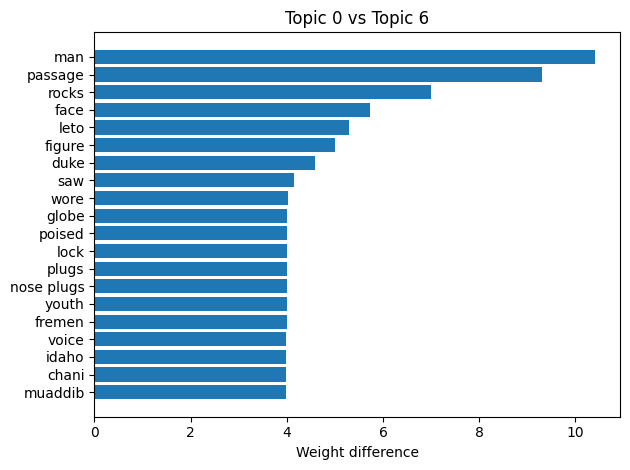

In [17]:
compare_two_topics(lda, feature_names, topic_a=0, topic_b=6, n_words=20)

The graph literally says that topics 0 and 6 differ only in a couple of words, and LDA cannot separate them effectively.

## 4. Character analysis using TF-IDF and SBERT

In this section, I analyzed characters using both TF-IDF and SBERT embeddings.

TF-IDF described characters through the words that were most uniquely associated with them, revealing their narrative attributes, environments, and recurring motifs.

SBERT, on the other hand, captured broader semantic and contextual relationships between characters. Instead of focusing on individual words, it reflected similarities in narrative roles, situations, and surrounding contexts.

I consider these two approaches complementary:

TF-IDF provides a more lexical and descriptive perspective,
while SBERT captures higher-level semantic structure and character relationships.

Together, they provide a more complete representation of the characters within the novel.

### разделим текст по персонажам

In [2]:
with open("dune.txt", "r", encoding="Windows-1252") as f:
    text = f.read()

In [3]:
# простое разбиение на предложения
sentences = re.split(r'[.!?]+', text)

# очистка
sentences = [s.strip() for s in sentences if len(s.strip()) > 50]

In [4]:
characters = {
    "paul": ["paul", "muaddib"],
    "jessica": ["jessica"],
    "leto": ["leto", "duke"],
    "chani": ["chani"],
    "baron": ["baron", "harkonnen"],
    "hawat": ["hawat"],
    "gurney": ["gurney"],
    "yueh": ["yueh"],
    "stilgar": ["stilgar"]
}

In [5]:
character_texts = {name: [] for name in characters}

for sent in sentences:
    sent_lower = sent.lower()
    
    for char_name, aliases in characters.items():
        if any(alias in sent_lower for alias in aliases):
            character_texts[char_name].append(sent)

In [6]:
for char_name in character_texts:
    character_texts[char_name] = " ".join(character_texts[char_name])

In [7]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower()

for char_name in character_texts:
    character_texts[char_name] = clean_text(character_texts[char_name])

In [8]:
for name, txt in character_texts.items():
    print(f"{name}: {len(txt.split())} words")

paul: 19681 words
jessica: 9532 words
leto: 8215 words
chani: 2945 words
baron: 9499 words
hawat: 3614 words
gurney: 3502 words
yueh: 1299 words
stilgar: 3923 words


### Анализ. TF-IDF

In [9]:
# превращаем словарь в список
names = list(character_texts.keys())
docs = [character_texts[name] for name in names]

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    max_df=0.8,
    min_df=2
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

In [10]:
def print_top_words_per_character(X, names, feature_names, top_n=15):
    for i, name in enumerate(names):
        row = X[i].toarray().flatten()
        
        top_indices = row.argsort()[::-1][:top_n]
        top_words = [feature_names[j] for j in top_indices]
        top_scores = [row[j] for j in top_indices]
        
        print(f"\n--- {name.upper()} ---")
        for w, s in zip(top_words, top_scores):
            print(f"{w:15} {s:.4f}")

print_top_words_per_character(X, names, feature_names)


--- PAUL ---
stilgar         0.2842
chani           0.2302
pack            0.1544
troop           0.1226
emperor         0.1083
jamis           0.1059
rock            0.1051
men             0.0992
rautha          0.0989
feyd            0.0989
ve              0.0902
fedaykin        0.0892
shield          0.0857
sensed          0.0851
lay             0.0813

--- JESSICA ---
lady            0.3007
chani           0.1967
stilgar         0.1928
bene            0.1625
gesserit        0.1625
water           0.1542
woman           0.1540
sensed          0.1112
dark            0.1026
harah           0.0967
alia            0.0953
daughter        0.0941
mouth           0.0941
feeling         0.0857
awareness       0.0857

--- LETO ---
hawat           0.2179
men             0.2161
thufir          0.1496
baron           0.1375
emperor         0.1179
water           0.1179
dead            0.1081
lady            0.1081
power           0.0981
caladan         0.0971
painting        0.0885
thinking    

### Второй TF-IDF без имён персонажей + персонаж muaddib

In [14]:
with open("dune.txt", "r", encoding="Windows-1252") as f:
    text = f.read()

sentences = re.split(r'[.!?]+', text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 50]

characters = {
    "paul": ["paul", "muaddib"],
    "jessica": ["jessica"],
    "leto": ["leto", "duke"],
    "chani": ["chani"],
    "baron": ["baron", "harkonnen"],
    "hawat": ["hawat"],
    "gurney": ["gurney"],
    "yueh": ["yueh"],
    "stilgar": ["stilgar"]
}

character_stopwords = [
    "paul", "muaddib",
    "jessica",
    "leto", "duke",
    "chani",
    "emperor",
    "baron", "harkonnen", "harkonnens",
    "hawat", "thufir",
    "gurney",
    "yueh",
    "stilgar",
    "feyd", "rautha", "rabban",
    "duncan", "idaho"
]

extra_stopwords = [
    "ve", "men", "man", "said", "one", "like"
]


all_stop_words = list(ENGLISH_STOP_WORDS.union(character_stopwords).union(extra_stopwords))

In [15]:
names = list(character_texts.keys())
docs = [character_texts[name] for name in names]

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=all_stop_words,
    max_df=0.8,
    min_df=2,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

print_top_words_per_character(X, names, feature_names)


--- PAUL ---
pack            0.1651
troop           0.1310
jamis           0.1132
rock            0.1123
fedaykin        0.0953
shield          0.0916
sensed          0.0909
lay             0.0869
woman           0.0856
water           0.0820
blade           0.0802
left hand       0.0802
dark            0.0802
silent          0.0774
slow            0.0755

--- JESSICA ---
lady            0.2996
bene            0.1619
bene gesserit   0.1619
gesserit        0.1619
water           0.1536
woman           0.1534
sensed          0.1108
dark            0.1022
harah           0.0963
alia            0.0949
daughter        0.0937
mouth           0.0937
awareness       0.0854
feeling         0.0854
mapes           0.0852

--- LETO ---
water           0.1243
dead            0.1139
lady            0.1139
power           0.1034
caladan         0.1023
painting        0.0933
thinking        0.0932
sudden          0.0932
long            0.0932
daughter        0.0919
learn           0.0860
deep        

### Анализ. SBERT

In [17]:
with open("dune.txt", "r", encoding="Windows-1252") as f:
    text = f.read()

text_lower = text.lower()

character_texts = {name: [] for name in characters}

sentences = re.split(r'[.!?]', text_lower)

for sent in sentences:
    for name in characters:
        if name in sent:
            character_texts[name].append(sent.strip())

for name in characters:
    character_texts[name] = " ".join(character_texts[name])

def remove_names(text, names):
    for name in names:
        text = text.replace(name, "")
    return text

character_texts_clean = {
    name: remove_names(text, characters)
    for name, text in character_texts.items()
}

In [18]:
model = SentenceTransformer('all-MiniLM-L6-v2')

names = list(character_texts_clean.keys())
docs = [character_texts_clean[name] for name in names]

embeddings = model.encode(docs, show_progress_bar=True)
embeddings.shape

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Batches: 100%|███████████████████████████████████| 1/1 [00:00<00:00,  1.49it/

(9, 384)

In [21]:
sim_matrix = cosine_similarity(embeddings)

df_sim = pd.DataFrame(sim_matrix, index=names, columns=names)
print(df_sim.round(3))

          paul  jessica   leto  chani  baron  hawat  gurney   yueh  stilgar
paul     1.000    0.336  0.474  0.378  0.395  0.415   0.359  0.471    0.305
jessica  0.336    1.000  0.513  0.380  0.354  0.375   0.335  0.444    0.502
leto     0.474    0.513  1.000  0.240  0.502  0.648   0.308  0.604    0.501
chani    0.378    0.380  0.240  1.000  0.422  0.264   0.385  0.393    0.326
baron    0.395    0.354  0.502  0.422  1.000  0.630   0.353  0.462    0.403
hawat    0.415    0.375  0.648  0.264  0.630  1.000   0.305  0.565    0.360
gurney   0.359    0.335  0.308  0.385  0.353  0.305   1.000  0.265    0.289
yueh     0.471    0.444  0.604  0.393  0.462  0.565   0.265  1.000    0.435
stilgar  0.305    0.502  0.501  0.326  0.403  0.360   0.289  0.435    1.000


In [22]:
for i, name in enumerate(names):
    sims = sim_matrix[i]
    sorted_idx = sims.argsort()[::-1]
    
    print(f"\n{name.upper()}:")
    for idx in sorted_idx[1:4]:
        print(f"  {names[idx]} → {sims[idx]:.3f}")


PAUL:
  leto → 0.474
  yueh → 0.471
  hawat → 0.415

JESSICA:
  leto → 0.513
  stilgar → 0.502
  yueh → 0.444

LETO:
  hawat → 0.648
  yueh → 0.604
  jessica → 0.513

CHANI:
  baron → 0.422
  yueh → 0.393
  gurney → 0.385

BARON:
  hawat → 0.630
  leto → 0.502
  yueh → 0.462

HAWAT:
  leto → 0.648
  baron → 0.630
  yueh → 0.565

GURNEY:
  chani → 0.385
  paul → 0.359
  baron → 0.353

YUEH:
  leto → 0.604
  hawat → 0.565
  paul → 0.471

STILGAR:
  jessica → 0.502
  leto → 0.501
  yueh → 0.435


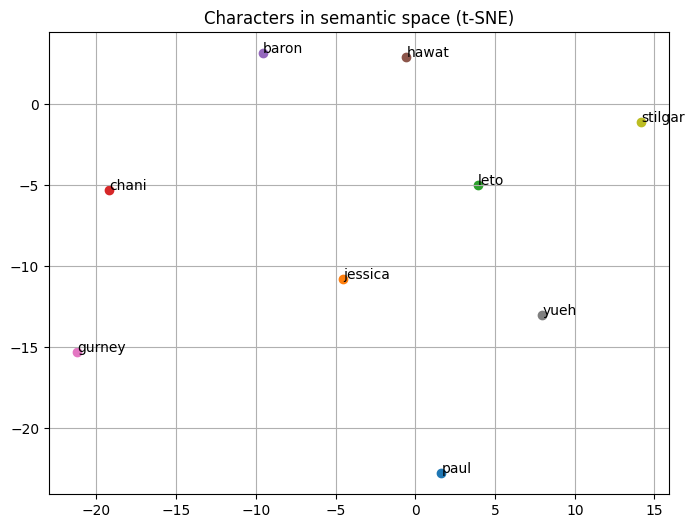

In [29]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))

for i, name in enumerate(names):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, name, fontsize=10)

plt.title("Characters in semantic space (t-SNE)")
plt.grid()

plt.show()

# Conclusions

1. LDA partially captured political and Fremen-related themes,
   but struggled with fine-grained character separation.

2. TF-IDF revealed strong contextual associations:
   - Jessica ↔ Bene Gesserit
   - Yueh ↔ betrayal / Suk conditioning

3. SBERT embeddings produced meaningful semantic relationships:
   - Leto ↔ Hawat
   - Baron ↔ Hawat
   - Jessica ↔ Stilgar

4. Semantic embeddings proved more expressive than bag-of-words methods.